In [33]:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from moabb.evaluations import WithinSessionEvaluation, CrossSessionEvaluation
from sklearn.pipeline import make_pipeline
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.svm import SVC

# 1. Define dataset and paradigm
dataset = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=35)
# Use only the 0train sessions for the testing

# 2. Build pipeline
pipelines = {
    # "RG+SVM": make_pipeline(
    #     Covariances(estimator='oas'),
    #     TangentSpace(metric='riemann'),
    #     SVC(kernel='rbf', C=1, class_weight='balanced', probability=True)
    # ),
    # "RG+LDA": make_pipeline(
    #     Covariances(estimator='oas'),
    #     TangentSpace(metric='riemann'),
    #     SVC(kernel='linear', C=1, class_weight='balanced', probability=True)
    # ),
    # "RG+KNN": make_pipeline(
    #     Covariances(estimator='oas'),
    #     TangentSpace(metric='riemann'),
    #     SVC(kernel='poly', C=1, class_weight='balanced', probability=True)
    # ),
    # "RG+RF": make_pipeline(
    #     Covariances(estimator='oas'),
    #     TangentSpace(metric='riemann'),
    #     SVC(kernel='sigmoid', C=1, class_weight='balanced', probability=True)
    # ),
    "betaprime+SVM": make_pipeline(
        Covariances(estimator='oas'),
        TangentSpace(metric='riemann'),
        SVC(kernel=betaprime, C=1, class_weight='balanced', probability=True)
    )
}

# 3. Evaluate pipeline
evaluation =  CrossSessionEvaluation(paradigm=paradigm,
                                     datasets=[dataset],
                                     overwrite=False)

results = evaluation.process(pipelines)


Choosing from all possible events
BNCI2014-001-CrossSession:   0%|          | 0/9 [00:00<?, ?it/s]/Users/rishabhkumar/miniconda3/envs/bci_env/lib/python3.10/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 48 events (all good), 2 – 6 s (baseline off), ~8.1 MiB, data loaded,
 'left_hand': 12
 'right_hand': 12
 'feet': 12
 'tongue': 12>
  warn(f"warnEpochs {epochs}")
/Users/rishabhkumar/miniconda3/envs/bci_env/lib/python3.10/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 48 events (all good), 2 – 6 s (baseline off), ~8.1 MiB, data loaded,
 'left_hand': 12
 'right_hand': 12
 'feet': 12
 'tongue': 12>
  warn(f"warnEpochs {epochs}")
/Users/rishabhkumar/miniconda3/envs/bci_env/lib/python3.10/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 48 events (all good), 2 – 6 s (baseline off), ~8.1 MiB, data loaded,
 'left_hand': 12
 'right_hand': 12
 'feet': 12
 'tongue': 12>
  warn(f"warnEp

LinAlgError: Last 2 dimensions of the array must be square

In [ ]:
# Riemannian Kernel for SVM
# How is the rbf kernel defined in code
S

In [ ]:
# data = dataset.get_data()
print(data)

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9])


In [ ]:
# 5. Print results
print("Results for CrossSessionEvaluation:")
print(results)

       score      time  samples subject session  channels  n_sessions  \
0   0.795463  0.242660    288.0       1  0train        22           2   
1   0.795402  0.234555    288.0       1   1test        22           2   
2   0.590260  0.247947    288.0       2  0train        22           2   
3   0.468966  0.211355    288.0       2   1test        22           2   
4   0.847368  0.237376    288.0       3  0train        22           2   
5   0.833575  0.227301    288.0       3   1test        22           2   
6   0.569268  0.270805    288.0       4  0train        22           2   
7   0.718935  0.227877    288.0       4   1test        22           2   
8   0.413188  0.250425    288.0       5  0train        22           2   
9   0.478947  0.243484    288.0       5   1test        22           2   
10  0.541440  0.262410    288.0       6  0train        22           2   
11  0.489595  0.256629    288.0       6   1test        22           2   
12  0.819661  0.227465    288.0       7  0train    

In [7]:
from pyriemann.estimation import Covariances

# X: array of shape (n_trials, n_channels, n_times)
covs = Covariances(estimator='oas').transform(X)

NameError: name 'X' is not defined

In [ ]:
from pyriemann.tangentspace import TangentSpace

ts = TangentSpace(metric='riemann')
features = ts.fit_transform(covs)

In [ ]:
from pyriemann.classification import SVC

clf = SVC(
    metric='riemann',        # kernel metric: 'riemann', 'logeuclid', etc.
    kernel_fct='precomputed',# use precomputed Gram matrix via pyRiemann’s utils.kernel
    Cref=None,               # reference matrix for centering (None → geometric mean)
    C=1.0,                   # regularization parameter as in the original paper
    shrinking=True,
    probability=False,
    random_state=42
)

In [ ]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    Covariances(estimator='oas'),
    SVC(metric='riemann', kernel_fct='precomputed', C=1.0, random_state=42)
)

In [ ]:
pipeline.fit(X, y)
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
print(f"Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

In [ ]:
from pyriemann.utils.kernel import kernel

# Compute Gram matrix for training
K_train = kernel(covs, covs, metric='riemann')
# Fit SVC with precomputed kernel
from sklearn.svm import SVC as SKSVC
svc_pre = SKSVC(kernel='precomputed', C=1.0, random_state=42)
svc_pre.fit(K_train, y)

# For testing:
covs_test = Covariances(estimator='oas').transform(X_test)
K_test = kernel(covs_test, covs, metric='riemann')
y_pred = svc_pre.predict(K_test)

In [3]:
import mne

# Load .gdf file
raw = mne.io.read_raw_gdf('A01T.gdf', preload=True)

# Bandpass filter (e.g., 8-35 Hz for MI tasks)
raw.filter(8., 35., fir_design='firwin')

# Find event markers (triggers) in the raw data
events, event_id = mne.events_from_annotations(raw)

# Epoch: extract windows (trials) time-locked to events (e.g., 0-4s post-cue)
# epochs = mne.Epochs(raw, events, event_id=event_id, tmin=0, tmax=4, baseline=None, preload=True)
epochs = mne.Epochs(
    raw, 
    events, 
    event_id=event_id, 
    tmin=0, 
    tmax=4, 
    baseline=None, 
    preload=True,
    event_repeated='drop'  # <--- Add this line
)

Extracting EDF parameters from /Users/rishabhkumar/Kernel-Experiments/experiments/bci-competition/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Users/rishabhkumar/miniconda3/envs/bci_env/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
585 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 585 events and 1001 original time points ...
0 bad epochs dropped


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:    0.2s finished


In [4]:
import numpy as np

X = epochs.get_data()[0]  # one trial: shape (n_channels, n_times)
X_centered = X - X.mean(axis=1, keepdims=True)
cov = np.dot(X_centered, X_centered.T) / (X.shape[1] - 1)

In [13]:
from pyriemann.estimation import Covariances
X_epochs = epochs.get_data()  # shape (n_trials, n_channels, n_times)
cov_matrices = Covariances(estimator='oas').transform(X_epochs)

In [15]:
print(cov)

[[1.12101308e-10 1.02063696e-10 1.07325304e-10 1.05918626e-10
  1.08446192e-10 1.07366002e-10 9.01810223e-11 9.82764152e-11
  1.01248346e-10 1.06129207e-10 1.02448024e-10 1.01320954e-10
  9.51755347e-11 9.45555869e-11 9.59787035e-11 9.33684063e-11
  9.16712731e-11 9.30778718e-11 8.78667035e-11 8.92304251e-11
  8.66576736e-11 7.78779270e-11 1.02267218e-10 1.13531389e-10
  7.58979185e-11]
 [1.02063696e-10 1.03091034e-10 1.03331336e-10 9.73114080e-11
  9.98293467e-11 9.79392865e-11 9.00432486e-11 9.89058304e-11
  9.97688881e-11 1.02073141e-10 9.66073195e-11 9.49776358e-11
  8.85174144e-11 9.59041486e-11 9.51814072e-11 9.16307453e-11
  8.80488713e-11 8.90538611e-11 8.83986357e-11 8.85981077e-11
  8.48051836e-11 7.91865174e-11 1.02087296e-10 1.01938226e-10
  7.08203982e-11]
 [1.07325304e-10 1.03331336e-10 1.08133863e-10 1.05057133e-10
  1.06358828e-10 1.03771973e-10 9.05197653e-11 9.99229634e-11
  1.03791992e-10 1.07064008e-10 1.02532243e-10 9.99095348e-11
  9.29841955e-11 9.70973642e-11 9.

In [14]:
print(cov_matrices[0])  # should be (n_trials, n_channels, n_channels)


[[1.12059288e-10 1.01642673e-10 1.06882577e-10 1.05481702e-10
  1.07998842e-10 1.06923107e-10 8.98090171e-11 9.78710158e-11
  1.00830687e-10 1.05691414e-10 1.02025416e-10 1.00902996e-10
  9.47829268e-11 9.41655362e-11 9.55827824e-11 9.29832529e-11
  9.12931205e-11 9.26939169e-11 8.75042452e-11 8.88623412e-11
  8.63002026e-11 7.75566733e-11 1.01845356e-10 1.13063061e-10
  7.55848325e-11]
 [1.01642673e-10 1.03086181e-10 1.02905085e-10 9.69099894e-11
  9.94175413e-11 9.75352778e-11 8.96718118e-11 9.84978346e-11
  9.93573322e-11 1.01652080e-10 9.62088053e-11 9.45858442e-11
  8.81522718e-11 9.55085350e-11 9.47887750e-11 9.12527599e-11
  8.76856615e-11 8.86865056e-11 8.80339831e-11 8.82326322e-11
  8.44553543e-11 7.88598656e-11 1.01666176e-10 1.01517721e-10
  7.05282575e-11]
 [1.06882577e-10 1.02905085e-10 1.08108208e-10 1.04623762e-10
  1.05920088e-10 1.03343904e-10 9.01463629e-11 9.95107718e-11
  1.03363840e-10 1.06622359e-10 1.02109288e-10 9.94973986e-11
  9.26006270e-11 9.66968285e-11 9.

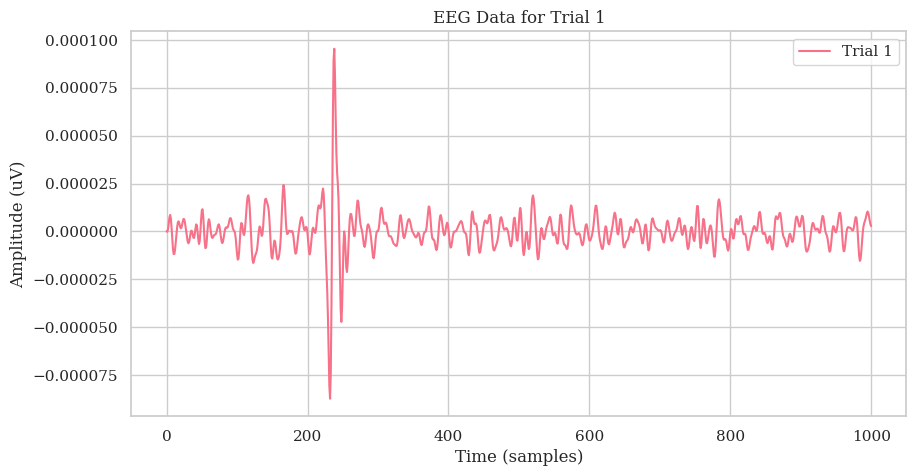

In [17]:
# plotting
import matplotlib.pyplot as plt
# Plot the data for the first trial
plt.figure(figsize=(10, 5))
plt.plot(X[0, :], label='Trial 1')
plt.title('EEG Data for Trial 1')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (uV)')
plt.legend()
plt.show()

In [30]:
# Define my own kernel function 
def betaprime(X, Y, alpha = X.shape[0] + 1):
    """
    Beta prime kernel function for covariance matrices
    """
    # Ensure X and Y are numpy arrays
    X = np.asarray(X)
    Y = np.asarray(Y)

    # Compute the beta prime kernel
    K = (np.linalg.det(X) * np.linalg.det(Y) / np.linalg.det(X + Y)**2) ** alpha
    
    return K

Beta prime kernel value: 2.064700221386156e-100


In [ ]:
# # Make an explicit pipeline rather than using make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# # After loading the data, compute the covariance matrices
# # Read data from the A01T.gdf file
# # Load the epochs
epochs = mne.read_epochs('A01T.gdf')  # Example of loading epochs
# covs = Covariances(estimator='oas').transform(X_epochs



Reading /Users/rishabhkumar/Kernel-Experiments/experiments/bci-competition/A01T.gdf ...


/var/folders/5r/6f18fbm17wl8t8q50sb5hrvc0000gn/T/ipykernel_1770/3807001506.py:9: RuntimeWarning: This filename (A01T.gdf) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs('A01T.gdf')  # Example of loading epochs


ValueError: file PosixPath('/Users/rishabhkumar/Kernel-Experiments/experiments/bci-competition/A01T.gdf') does not start with a file id tag

In [36]:
print(mne.events_from_annotations(raw))

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 29683,      0,      5],
       ...,
       [670550,      0,      6],
       [670550,      0,      1],
       [671050,      0,      7]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
